# **(Part 3)**

# **1. Distributed Model Development**

In [ ]:
# Mounted the Google Drive to access diabetes dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Create Spark session for distributed processing
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lit

spark = SparkSession.builder.appName("CO7093_Part3").getOrCreate()

In [ ]:
# Required to read the diabetes dataset stored in the drive
df = spark.read.csv('/content/drive/MyDrive/Colab Notebooks/Group_Project/diabetic_data.csv',header=True,inferSchema=True)
# Displays sample rows and dataset dimensions
df.show(5)
print("Rows:", df.count(), "Columns:", len(df.columns))

+------------+-----------+---------------+------+-------+------+-----------------+------------------------+-------------------+----------------+----------+--------------------+------------------+--------------+---------------+-----------------+----------------+----------------+------+------+------+----------------+-------------+---------+---------+-----------+-----------+--------------+-----------+-------------+---------+---------+-----------+------------+-------------+--------+--------+------------+----------+-------+-----------+-------+-------------------+-------------------+------------------------+-----------------------+----------------------+------+-----------+----------+
|encounter_id|patient_nbr|           race|gender|    age|weight|admission_type_id|discharge_disposition_id|admission_source_id|time_in_hospital|payer_code|   medical_specialty|num_lab_procedures|num_procedures|num_medications|number_outpatient|number_emergency|number_inpatient|diag_1|diag_2|diag_3|number_diagnos

In [ ]:
# Print schema to understand all the data types
df.printSchema()

root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagnoses: integer (nullable = true)
 |-

In [ ]:
# Replace missing value placeholders ? with nulls
df = df.replace("?", None)

In [ ]:
# Ensure target column is string and removes the whitespace
from pyspark.sql.functions import col,when,trim
df=df.withColumn("readmitted",col("readmitted").cast("string"))

In [ ]:
df=df.withColumn("readmitted",trim(col("readmitted")))

In [ ]:
# Converts categorical targets into numerical labels
df=df.withColumn(
    "readmitted",
    when(col("readmitted")=="NO",0.0)
    .when(col("readmitted")=="<30",1.0)
    .when(col("readmitted")==">30",2.0)
    .otherwise(None)
)

In [ ]:
# This is done to confirm the transformation of labels for readmitted
df.select("readmitted").distinct().show()

+----------+
|readmitted|
+----------+
|       0.0|
|       1.0|
|       2.0|
+----------+



In [ ]:
# Calculates missing values
total_rows=df.count()
missing_ratio = {
    c: df.filter(col(c).isNull()).count() / total_rows
    for c in df.columns
}
# Drops the columns with >30% missing values
threshold = 0.3

valid_cols = [c for c in df.columns if missing_ratio[c] < threshold]

df = df.select(valid_cols)
# Displays the remaining columns
print("Columns after threshold:", df.columns)

Columns after threshold: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [ ]:
#build feature columns from this selecting the numeric columns only and excludes encounter_id","patient_nbr
numeric_cols = [c for c, t in df.dtypes if t in ["int", "bigint", "double", "float", "long", "short"]
                and c not in ["encounter_id","patient_nbr"]]
numeric_cols

['admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'readmitted']

In [ ]:
#excluding targets from features
feature_cols = [c for c in numeric_cols if c != "readmitted"]
print("Numeric feature columns:", feature_cols)

Numeric feature columns: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [ ]:
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
# converting taget to double
df = df.withColumn("readmitted", col("readmitted").cast("double"))

# Assembles features into a single vector column
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

data = assembler.transform(df)
data.select("features", "readmitted").show(5, truncate=False)

+-----------------------------------------------+----------+
|features                                       |readmitted|
+-----------------------------------------------+----------+
|[6.0,25.0,1.0,1.0,41.0,0.0,1.0,0.0,0.0,0.0,1.0]|0.0       |
|[1.0,1.0,7.0,3.0,59.0,0.0,18.0,0.0,0.0,0.0,9.0]|2.0       |
|[1.0,1.0,7.0,2.0,11.0,5.0,13.0,2.0,0.0,1.0,6.0]|0.0       |
|[1.0,1.0,7.0,2.0,44.0,1.0,16.0,0.0,0.0,0.0,7.0]|0.0       |
|[1.0,1.0,7.0,1.0,51.0,0.0,8.0,0.0,0.0,0.0,5.0] |0.0       |
+-----------------------------------------------+----------+
only showing top 5 rows


In [ ]:
#train test split
train_df, test_df = data.randomSplit([0.8, 0.2], seed=42)

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

Train rows: 81391
Test rows: 20375


In [ ]:
#fit global model
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="readmitted",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    numTrees=100,
    seed=42
)

global_model = rf.fit(train_df)
global_preds = global_model.transform(test_df)

In [ ]:
#evaluate global model performance
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="readmitted",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="readmitted",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_prec = MulticlassClassificationEvaluator(
    labelCol="readmitted",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

evaluator_rec = MulticlassClassificationEvaluator(
    labelCol="readmitted",
    predictionCol="prediction",
    metricName="weightedRecall"
)

print("Global Random Forest Accuracy:", evaluator_acc.evaluate(global_preds))
print("Global Random Forest Precision:", evaluator_prec.evaluate(global_preds))
print("Global Random Forest Recall:", evaluator_rec.evaluate(global_preds))
print("Global Random Forest F1:", evaluator_f1.evaluate(global_preds))

Global Random Forest Accuracy: 0.5793865030674846
Global Random Forest Precision: 0.500714592822988
Global Random Forest Recall: 0.5793865030674847
Global Random Forest F1: 0.5225362197255432


In [ ]:
global_preds.groupBy("prediction").count().show()


+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|15638|
|       2.0| 4737|
+----------+-----+



# **2. Clustering Analysis**

In [ ]:
from pyspark.ml.feature import StandardScaler

# Scale features to normalize data before clustering
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(data)
data = scaler_model.transform(data)

# debugging error syntax to confirm it exists
print("Columns now:", data.columns)
data.printSchema()

# Apply KMeans clustering
from pyspark.ml.clustering import KMeans

kmeans_spark = KMeans(featuresCol="scaled_features", k=2, seed=42)

model = kmeans_spark.fit(data)
# Assign cluster labels
clustered = model.transform(data)
# Analyse cluster distribution and target behaviour
clustered.groupBy("prediction").count().show()
clustered.groupBy("prediction").mean("readmitted").show()

Columns now: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'features', 'scaled_features']
root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: strin

In [ ]:
data = assembler.transform(df)

In [ ]:
# Using the dataframe that contains the feature column
sample_df = data.select("features").sample(fraction=0.2, seed=42).toPandas()

# Convert Spark into a NumPy array to define the scaled_features
scaled_features = np.array(
    sample_df['features'].apply(lambda x: x.toArray()).tolist()
)

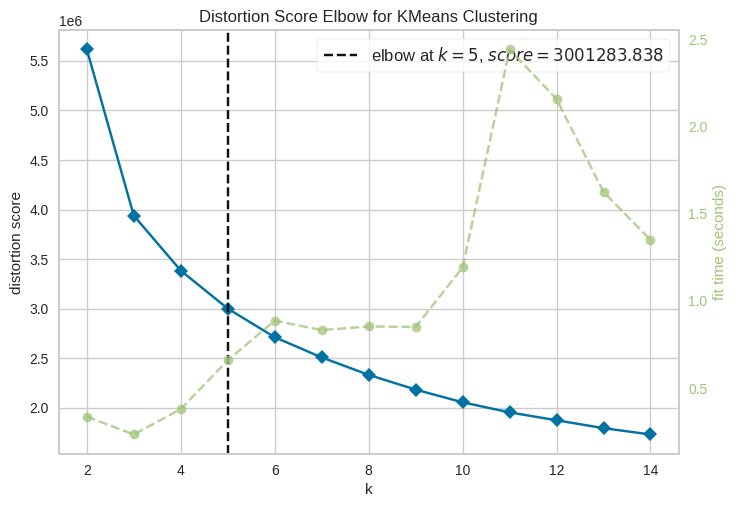

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans(random_state=42, n_init=10)

# Elbow method used to find the optimal number of clusters
visualizer = KElbowVisualizer(model, k=(2,15)) # After playing with the ranges discovered (2,15) was best for both elbow and silhouette
visualizer.fit(scaled_features)
visualizer.show()

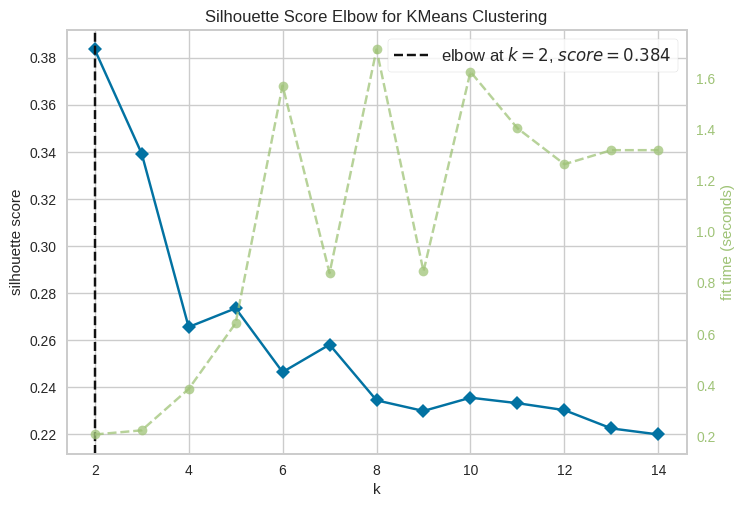

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
# Silhouette score is a more precise method to find the optimal number of clusters
visualizer = KElbowVisualizer(
    model,
    k=(2,15),
    metric='silhouette'
)

visualizer.fit(scaled_features)
visualizer.show()

In [ ]:
optimal_k = visualizer.elbow_value_
print("Optimal k from silhouette:", optimal_k)

Optimal k from silhouette: 2


In [ ]:
from pyspark.ml.clustering import KMeans

kmeans_spark = KMeans(featuresCol="features", k=2, seed=42)

model = kmeans_spark.fit(data)
cluster_cell= model.transform(data)

clustered.groupBy("prediction").count().show()
clustered.groupBy("prediction").mean("readmitted").show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|36159|
|         0|65607|
+----------+-----+

+----------+------------------+
|prediction|   avg(readmitted)|
+----------+------------------+
|         1|0.8856439613927376|
|         0|0.7685612815705641|
+----------+------------------+



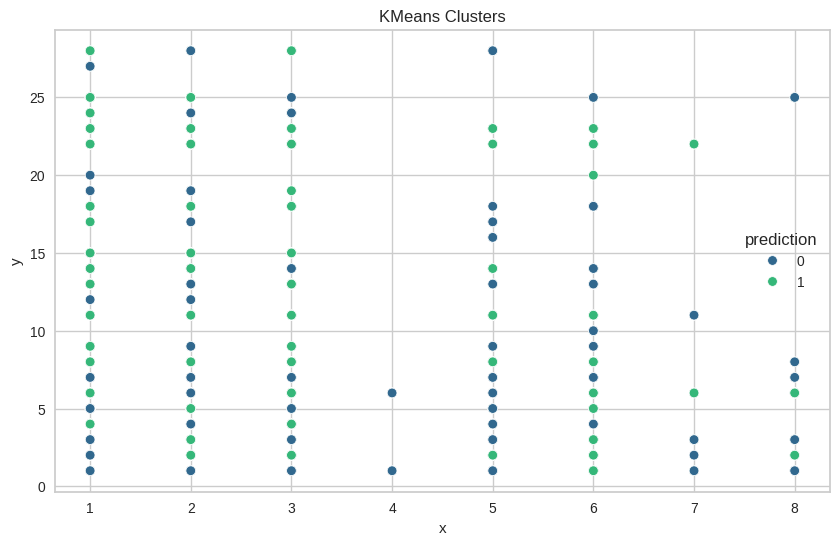

In [ ]:
# Import seaborn for data visualisation
import seaborn as sns

# Convert Spark DataFrame to Pandas for plotting as Seaborn and matplotlib do not support Spark DataFrames directly
plot_df = clustered.select("features", "prediction").toPandas()

# Extract first feature value for x-axis and second feature from the y-axis allowing for 2D visualisation
plot_df["x"] = plot_df["features"].apply(lambda v: float(v[0]))
plot_df["y"] = plot_df["features"].apply(lambda v: float(v[1]))

# Set figure size for better readability
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="x",
    y="y",
    hue="prediction",
    data=plot_df,
    palette="viridis" # Colour scheme for clusters
)
# Add plot title
plt.title("KMeans Clusters")
# Display plot
plt.show()

In [ ]:
clustered.groupBy("prediction").count().show()

clustered.groupBy("prediction").mean().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|36159|
|         0|65607|
+----------+-----+

+----------+-------------------+--------------------+----------------------+-----------------------------+------------------------+---------------------+-----------------------+-------------------+--------------------+----------------------+---------------------+---------------------+---------------------+------------------+---------------+
|prediction|  avg(encounter_id)|    avg(patient_nbr)|avg(admission_type_id)|avg(discharge_disposition_id)|avg(admission_source_id)|avg(time_in_hospital)|avg(num_lab_procedures)|avg(num_procedures)|avg(num_medications)|avg(number_outpatient)|avg(number_emergency)|avg(number_inpatient)|avg(number_diagnoses)|   avg(readmitted)|avg(prediction)|
+----------+-------------------+--------------------+----------------------+-----------------------------+------------------------+---------------------+-----------------------+-------------------+--

In [ ]:
from pyspark.ml.feature import PCA

pca = PCA(
    k=2, # It is done on 2 dimensions
    inputCol="features",
    outputCol="pcaFeatures"
)

# fit model
pca_model = pca.fit(data)

# transform data
data_reduced = pca_model.transform(data).select("pcaFeatures", "readmitted")

data_reduced.show(5, truncate=False)

+---------------------------------------+----------+
|pcaFeatures                            |readmitted|
+---------------------------------------+----------+
|[40.940827013170605,1.1373652526636344]|0.0       |
|[61.12619761312025,-9.962158259104402] |2.0       |
|[12.90078519696554,-11.907188025092072]|0.0       |
|[45.940544446401205,-9.92232880178361] |0.0       |
|[51.72392844701407,-0.9023972077539602]|0.0       |
+---------------------------------------+----------+
only showing top 5 rows


# **3. Cluster-Based Classification**

In [ ]:
# Extract unique cluster IDs
clusters = [row["prediction"] for row in clustered.select("prediction").distinct().collect()]

cluster_results = []

In [ ]:
from pyspark.sql.functions import col
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

results = []  # store results for summary

clusters = [row['prediction'] for row in clustered.select("prediction").distinct().collect()]

# Train a separate Random Forest model per cluster
# This captures local patterns within each cluster
for cluster_id in clusters:
    print(f"\n===== Cluster {cluster_id} =====")

# Filter data for current cluster
    cluster_df = clustered.filter(col("prediction") == cluster_id)

    size = cluster_df.count()
    print("Cluster size:", size)

    # Skip very small clusters
    if size <= 50:
        print(f"Cluster {cluster_id} skipped (too small)")
        continue

    # Train/test split
    train_c, test_c = cluster_df.randomSplit([0.8, 0.2], seed=42)

    # Random Forest model
    rf_cluster = RandomForestClassifier(
        featuresCol="features",
        labelCol="readmitted",
        predictionCol="rf_prediction",
        probabilityCol="rf_probability",
        rawPredictionCol="rf_rawPrediction",
        numTrees=100,
        seed=42
    )

    # Train
    cluster_model = rf_cluster.fit(train_c)

    # Predict
    preds = cluster_model.transform(test_c)

    # Evaluators
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="readmitted",
        predictionCol="rf_prediction",
        metricName="accuracy"
    )

    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="readmitted",
        predictionCol="rf_prediction",
        metricName="f1"
    )

    acc = evaluator_acc.evaluate(preds)
    f1 = evaluator_f1.evaluate(preds)

    print("Accuracy:", acc)
    print("F1:", f1)

    results.append((cluster_id, acc, f1, cluster_df.count()))



===== Cluster 1 =====
Cluster size: 36159
Accuracy: 0.5531795160382668
F1: 0.5062144253930048

===== Cluster 0 =====
Cluster size: 65607
Accuracy: 0.602829245790728
F1: 0.5320995336844339


In [ ]:
# Computes the average performance across clusters
# This provides overall effectiveness of cluster-based approach
total_size=sum(r[3]for r in results)
avg_acc = sum(r[1]*r[3] for r in results) / total_size
avg_f1 = sum(r[2]*r[3] for r in results) / total_size

print("\n===== FINAL SUMMARY =====")
print("Average Accuracy:", avg_acc)
print("Average F1:", avg_f1)



===== FINAL SUMMARY =====
Average Accuracy: 0.5851879453748795
Average F1: 0.5229021629446015


In [ ]:
# Comparison between Cluster based And Global Model Score
# This determines whether clustering improves prediction performance
print("Cluster-Based Avg Accuracy:", avg_acc)
print("Cluster-Based Avg F1:", avg_f1)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="readmitted",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="readmitted",
    predictionCol="prediction",
    metricName="f1"
)
global_acc = evaluator_acc.evaluate(global_preds)
global_f1 = evaluator_f1.evaluate(global_preds)

print("Global Random Forest Accuracy:", global_acc)
print("Global Random Forest F1:", global_f1)

Cluster-Based Avg Accuracy: 0.5851879453748795
Cluster-Based Avg F1: 0.5229021629446015
Global Random Forest Accuracy: 0.5793865030674846
Global Random Forest F1: 0.5225362197255432
